In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import rcParams
from matplotlib import pyplot as plt
%matplotlib inline

In [35]:
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [36]:
lstm_history = pd.read_csv('training_hists/LSTM_FC_history.csv')
gru_history = pd.read_csv('training_hists/GRU_FC_history.csv')

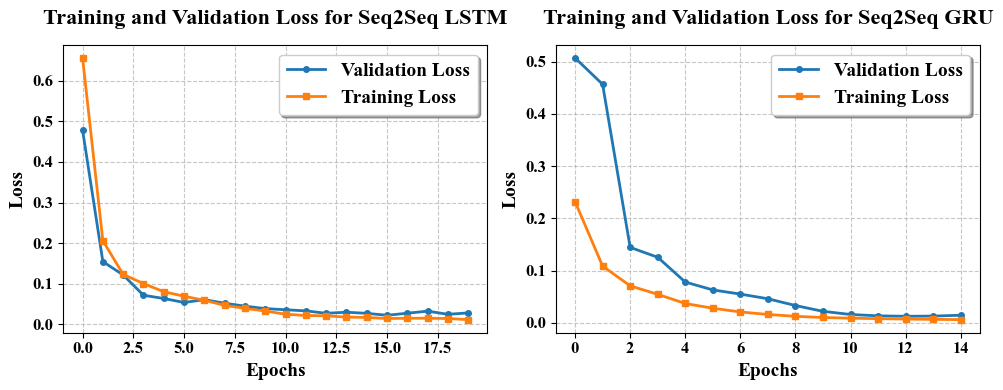

In [37]:
plt.figure(figsize=(10, 4))

# LSTM plot
plt.subplot(1, 2, 1)
plt.plot(lstm_history['val_loss'], label='Validation Loss', linewidth=2, marker='o', markersize=4)
plt.plot(lstm_history['loss'], label='Training Loss', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=14, weight='bold')
plt.ylabel('Loss', fontsize=14, weight='bold')
plt.title('Training and Validation Loss for Seq2Seq LSTM', fontsize=16, pad=15, weight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, prop={'weight': 'bold','size':14})
plt.xticks(weight='bold',fontsize=12)
plt.yticks(weight='bold',fontsize=12)

# GRU plot
plt.subplot(1, 2, 2)
plt.plot(gru_history['val_loss'], label='Validation Loss', linewidth=2, marker='o', markersize=4)
plt.plot(gru_history['loss'], label='Training Loss', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=14, weight='bold')
plt.ylabel('Loss', fontsize=14, weight='bold')
plt.title('Training and Validation Loss for Seq2Seq GRU', fontsize=16, pad=15, weight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, prop={'weight': 'bold','size':14})
plt.xticks(weight='bold',fontsize=12)
plt.yticks(weight='bold',fontsize=12)

plt.tight_layout()
plt.show()


In [38]:
df_lstm = pd.read_csv(f"simulations/LSTM_predictions.csv")
df_gru = pd.read_csv(f"simulations/GRU_predictions.csv")

In [39]:
from utils import plot_timeseries_with_splits, calc_metrics

targets = ['Die Temp', 'SME-Watt']
labels = ['Die Temperature [C]', 'Mechanical Energy [Kj/Kg]']

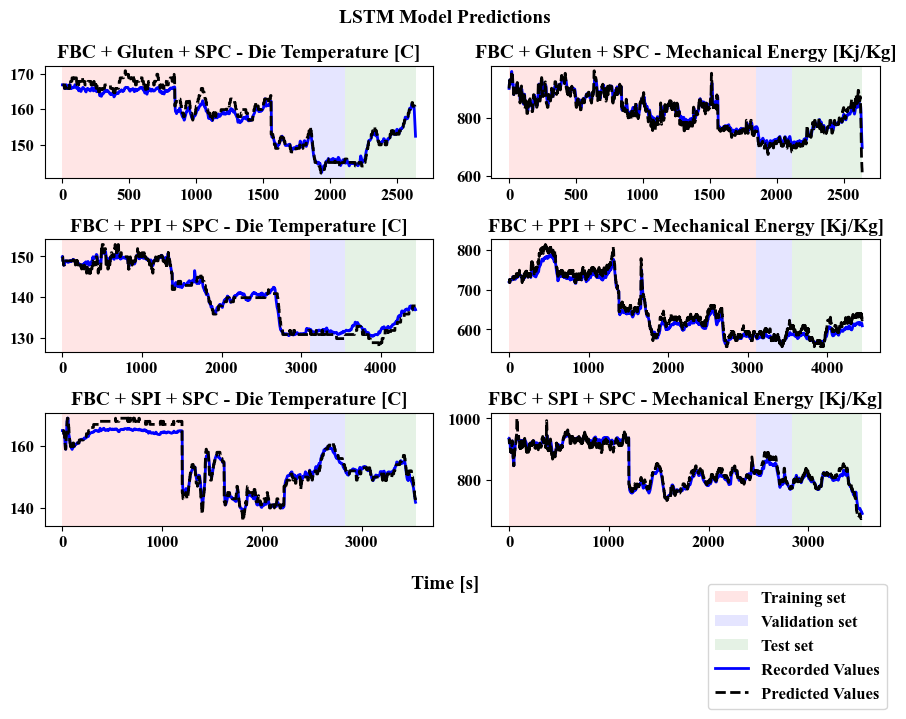

In [40]:
# Time series plots for LSTM
fig, axes = plt.subplots(3, 2, figsize=(9, 6))

for row, group_name in enumerate(df_lstm['group'].unique()):
    group_df = df_lstm[df_lstm['group'] == group_name]
    
    for col, (target, label) in enumerate(zip(targets, labels)):
        pred_col = f'{target}_pred'
        title = f'{group_name} - {label}'
        plot_timeseries_with_splits(axes[row, col], group_df, target, pred_col, title)

fig.supxlabel('Time [s]', fontsize=14, fontweight='bold')
fig.suptitle('LSTM Model Predictions', fontsize=14, fontweight='bold')
fig.legend(['Training set','Validation set','Test set','Recorded Values','Predicted Values'], 
           loc='lower right', bbox_to_anchor=(1, -0.2), prop={'weight': 'bold', 'size': 12})
fig.tight_layout()
plt.show()

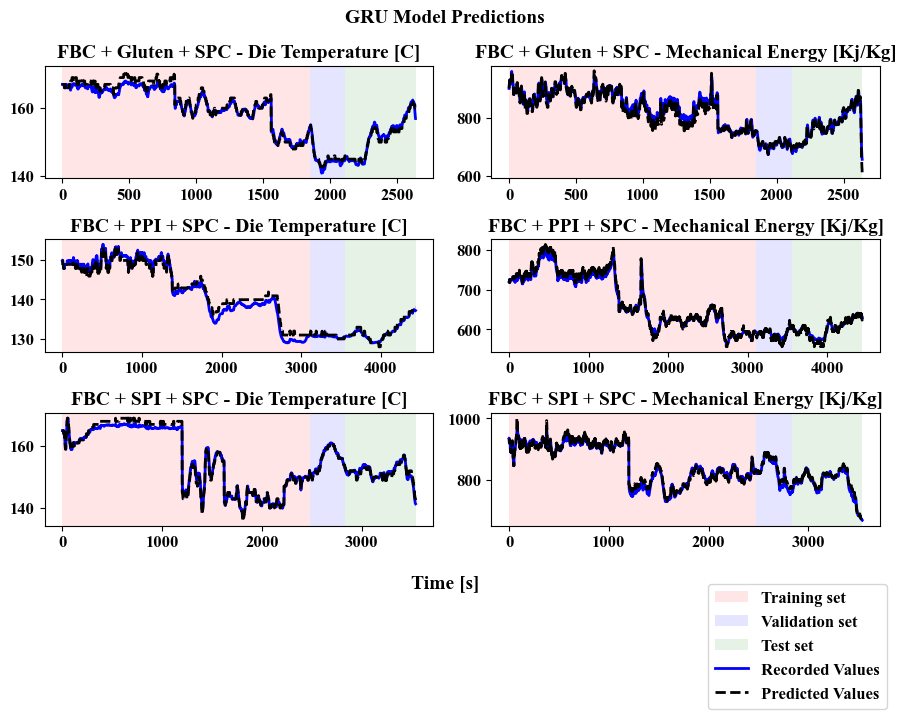

In [41]:
# Time series plots for GRU
fig, axes = plt.subplots(3, 2, figsize=(9, 6))

for row, group_name in enumerate(df_gru['group'].unique()):
    group_df = df_gru[df_gru['group'] == group_name]
    
    for col, (target, label) in enumerate(zip(targets, labels)):
        pred_col = f'{target}_pred'
        title = f'{group_name} - {label}'
        plot_timeseries_with_splits(axes[row, col], group_df, target, pred_col, title)

fig.supxlabel('Time [s]', fontsize=14, fontweight='bold')
fig.suptitle('GRU Model Predictions', fontsize=14, fontweight='bold')
fig.legend(['Training set','Validation set','Test set','Recorded Values','Predicted Values'],
           loc='lower right', bbox_to_anchor=(1, -0.2), prop={'weight': 'bold', 'size': 12})
fig.tight_layout()
plt.show()

In [42]:
# Metrics table for LSTM
metrics_rows = []
for split in ['train', 'test']:
    split_df = df_lstm[df_lstm['Split'] == split]
    for target in targets:
        m = calc_metrics(split_df[target].values, split_df[f'{target}_pred'].values)
        metrics_rows.append({'Model': 'LSTM', 'Split': split, 'Target': target, **m})

lstm_metrics = pd.DataFrame(metrics_rows)
display(lstm_metrics)

,Model,Split,Target,NRMSE,MAE,MB
0,LSTM,train,Die Temp,0.041737,1.235431,-0.665735
1,LSTM,train,SME-Watt,0.029444,10.287476,-3.203756
2,LSTM,test,Die Temp,0.035792,0.940967,0.537989
3,LSTM,test,SME-Watt,0.044840,12.030164,-5.593021


In [43]:
# Metrics table for GRU
metrics_rows = []
for split in ['train', 'test']:
    split_df = df_gru[df_gru['Split'] == split]
    for target in targets:
        m = calc_metrics(split_df[target].values, split_df[f'{target}_pred'].values)
        metrics_rows.append({'Model': 'GRU', 'Split': split, 'Target': target, **m})

gru_metrics = pd.DataFrame(metrics_rows)
display(gru_metrics)

,Model,Split,Target,NRMSE,MAE,MB
0,GRU,train,Die Temp,0.031925,1.024749,-0.481369
1,GRU,train,SME-Watt,0.024562,8.323396,-0.766737
2,GRU,test,Die Temp,0.019484,0.536544,0.020820
3,GRU,test,SME-Watt,0.024735,6.112788,-0.842332
